In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery

PROJECT_ID = "nyc-taxi-analytics-1"

client = bigquery.Client(project=PROJECT_ID)

def run_query(query: str) -> pd.DataFrame:
    query_job = client.query(query)
    return query_job.result().to_dataframe()

In [4]:
query_pickup = f"""
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    pickup_service_zone,
    total_trips,
    total_revenue,
    total_tip,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    demand_rank,
    revenue_rank,
    trip_share_percentage,
    revenue_share_percentage
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_pickup_location_performance`
ORDER BY total_trips DESC
LIMIT 20
"""

df_pickup = run_query(query_pickup)
df_pickup.head()

,pickup_location_id,pickup_borough,pickup_zone,pickup_service_zone,total_trips,total_revenue,total_tip,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes,demand_rank,revenue_rank,trip_share_percentage,revenue_share_percentage
0,132,Queens,JFK Airport,Airports,1879779,1.533402e+08,16873110.06,81.57,16.34,43.84,1,1,5.32,15.02
1,237,Manhattan,Upper East Side South,Yellow Zone,1700623,3.514418e+07,4588303.44,20.67,1.81,12.91,2,4,4.81,3.44
2,161,Manhattan,Midtown Center,Yellow Zone,1673973,4.235036e+07,5488232.91,25.30,2.57,16.39,3,3,4.73,4.15
3,236,Manhattan,Upper East Side North,Yellow Zone,1499585,3.179400e+07,4193975.05,21.20,2.03,13.04,4,6,4.24,3.11
4,162,Manhattan,Midtown East,Yellow Zone,1289563,3.157371e+07,4118831.75,24.48,2.45,15.47,5,7,3.65,3.09


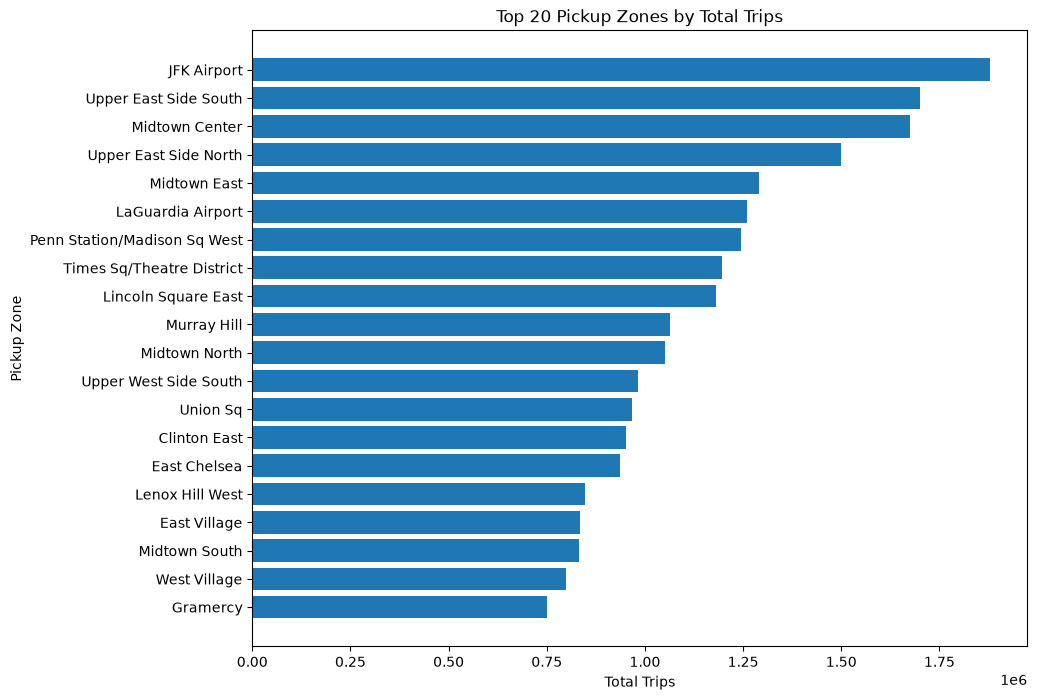

In [5]:
pickup_chart = df_pickup.sort_values("total_trips", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(
    pickup_chart["pickup_zone"],
    pickup_chart["total_trips"]
)
plt.title("Top 20 Pickup Zones by Total Trips")
plt.xlabel("Total Trips")
plt.ylabel("Pickup Zone")
plt.show()

In [7]:
query_dropoff = f"""
SELECT
    dropoff_location_id,
    dropoff_borough,
    dropoff_zone,
    dropoff_service_zone,
    total_trips,
    total_revenue,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    arrival_rank,
    revenue_rank,
    trip_share_percentage,
    revenue_share_percentage
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_dropoff_location_performance`
ORDER BY total_trips DESC
LIMIT 20
"""

df_dropoff = run_query(query_dropoff)
df_dropoff.head()

,dropoff_location_id,dropoff_borough,dropoff_zone,dropoff_service_zone,total_trips,total_revenue,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes,arrival_rank,revenue_rank,trip_share_percentage,revenue_share_percentage
0,236,Manhattan,Upper East Side North,Yellow Zone,1584282,34481423.04,21.76,2.17,12.93,1,3,4.48,3.38
1,237,Manhattan,Upper East Side South,Yellow Zone,1517727,31323030.75,20.64,1.83,12.71,2,5,4.29,3.07
2,161,Manhattan,Midtown Center,Yellow Zone,1392241,34568330.86,24.83,2.48,16.40,3,2,3.94,3.39
3,230,Manhattan,Times Sq/Theatre District,Yellow Zone,1101305,35271603.54,32.03,3.75,21.60,4,1,3.11,3.45
4,170,Manhattan,Murray Hill,Yellow Zone,1060127,25703309.24,24.25,2.45,14.67,5,7,3.00,2.52


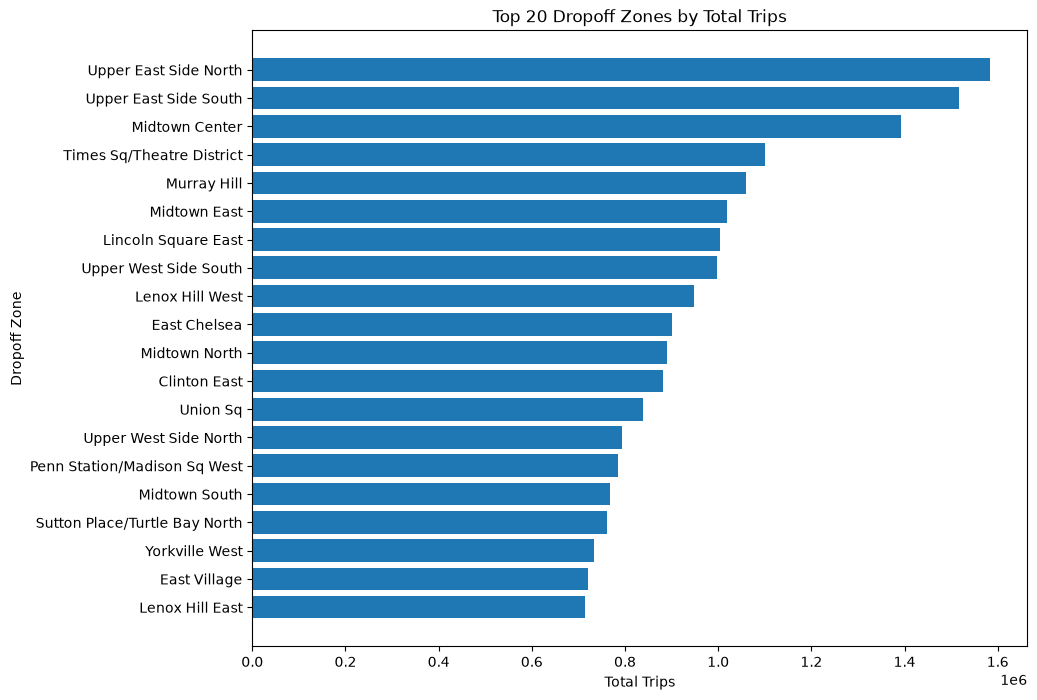

In [8]:
dropoff_chart = df_dropoff.sort_values("total_trips", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(
    dropoff_chart["dropoff_zone"],
    dropoff_chart["total_trips"]
)
plt.title("Top 20 Dropoff Zones by Total Trips")
plt.xlabel("Total Trips")
plt.ylabel("Dropoff Zone")
plt.show()

In [9]:
query_route = f"""
SELECT
    pickup_borough,
    pickup_zone,
    dropoff_borough,
    dropoff_zone,
    route_name,
    route_type,
    total_trips,
    total_revenue,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    demand_rank,
    revenue_rank
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_route_performance`
ORDER BY total_trips DESC
LIMIT 20
"""

df_route = run_query(query_route)
df_route.head()

,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone,route_name,route_type,total_trips,total_revenue,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes,demand_rank,revenue_rank
0,Manhattan,Upper East Side South,Manhattan,Upper East Side North,Upper East Side South → Upper East Side North,Within borough route,247644,3916288.56,15.81,1.08,8.37,1,7
1,Unknown,N/A,Unknown,N/A,N/A → N/A,Same zone route,246726,7012794.29,28.42,3.64,17.81,2,3
2,Manhattan,Upper East Side North,Manhattan,Upper East Side South,Upper East Side North → Upper East Side South,Within borough route,211103,3440165.76,16.30,1.09,9.04,3,13
3,Manhattan,Upper East Side South,Manhattan,Upper East Side South,Upper East Side South → Upper East Side South,Same zone route,164076,2284864.07,13.93,0.67,6.81,4,24
4,Manhattan,Upper East Side North,Manhattan,Upper East Side North,Upper East Side North → Upper East Side North,Same zone route,157444,2065458.70,13.12,0.71,5.74,5,29


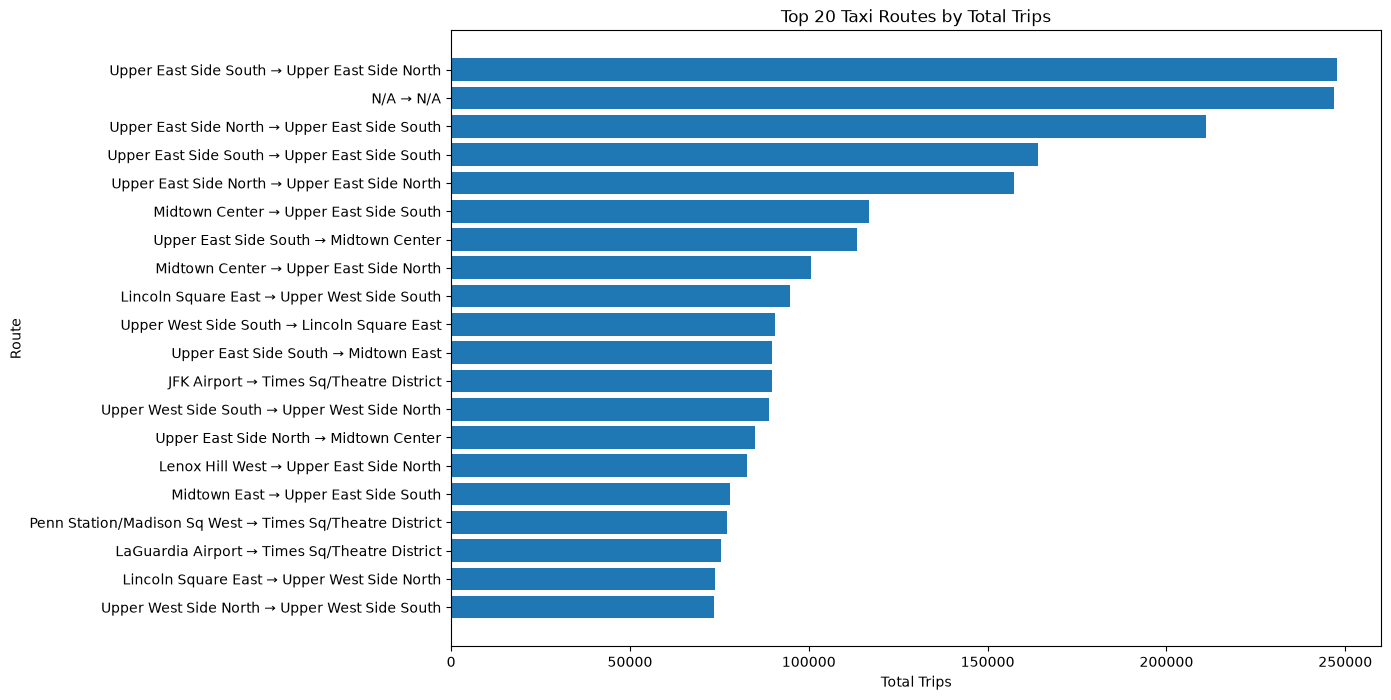

In [10]:
route_chart = df_route.sort_values("total_trips", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(
    route_chart["route_name"],
    route_chart["total_trips"]
)
plt.title("Top 20 Taxi Routes by Total Trips")
plt.xlabel("Total Trips")
plt.ylabel("Route")
plt.show()

In [11]:
query_borough_flow = f"""
SELECT
    pickup_borough,
    dropoff_borough,
    borough_trip_type,
    total_trips,
    total_revenue,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    demand_rank,
    revenue_rank
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_borough_flow_performance`
ORDER BY total_trips DESC
"""

df_borough_flow = run_query(query_borough_flow)
df_borough_flow.head()

,pickup_borough,dropoff_borough,borough_trip_type,total_trips,total_revenue,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes,demand_rank,revenue_rank
0,Manhattan,Manhattan,Within borough,29402702,6.257322e+08,21.28,1.99,13.87,1,1
1,Queens,Manhattan,Cross borough,2054641,1.679330e+08,81.73,14.36,42.32,2,2
2,Manhattan,Queens,Cross borough,1056430,7.150397e+07,67.68,11.40,37.80,3,3
3,Manhattan,Brooklyn,Cross borough,716409,3.143908e+07,43.88,6.45,29.28,4,5
4,Queens,Queens,Within borough,671893,2.888565e+07,42.99,7.77,22.18,5,6


In [13]:
print(df_borough_flow.dtypes)

pickup_borough                   str
dropoff_borough                  str
borough_trip_type                str
total_trips                    Int64
total_revenue                float64
avg_revenue_per_trip         float64
avg_trip_distance            float64
avg_trip_duration_minutes    float64
demand_rank                    Int64
revenue_rank                   Int64
dtype: object


In [14]:
print(borough_matrix.dtypes)

dropoff_borough
Bronx            Int64
Brooklyn         Int64
EWR              Int64
Manhattan        Int64
N/A              Int64
Queens           Int64
Staten Island    Int64
Unknown          Int64
dtype: object


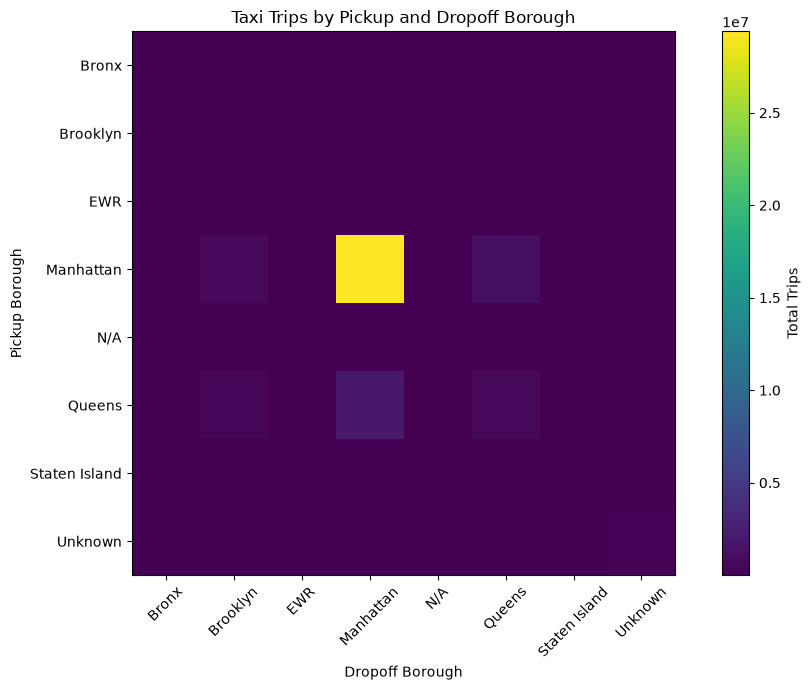

In [15]:
borough_matrix = (
    df_borough_flow
    .pivot(
        index="pickup_borough",
        columns="dropoff_borough",
        values="total_trips"
    )
    .fillna(0)
    .astype("int64")      # NumPy int64, bukan pandas Int64
)

plt.figure(figsize=(10, 7))
plt.imshow(borough_matrix)

plt.title("Taxi Trips by Pickup and Dropoff Borough")
plt.xlabel("Dropoff Borough")
plt.ylabel("Pickup Borough")

plt.xticks(
    ticks=range(len(borough_matrix.columns)),
    labels=borough_matrix.columns,
    rotation=45
)

plt.yticks(
    ticks=range(len(borough_matrix.index)),
    labels=borough_matrix.index
)

plt.colorbar(label="Total Trips")
plt.tight_layout()
plt.show()